# FX Hedge Comparison

We have ongoing AUD liabilities to be paid using our CNH holding. Forward contracts let us fix the rate today rather than convert at spot on the day. This script shows the cost and payoff of each hedge across a range of possible outcomes.

The parameters in the first cell can be customised. Following this, no input is required

In [ ]:
# Remove comment to install required libraries
# pip install yfinance pandas numpy matplotlib
import warnings; warnings.filterwarnings("ignore", module="yfinance")
import yfinance as yf, pandas as pd, numpy as np, matplotlib.pyplot as plt

#-----#-----#-----#-----#-----INPUT PARAMETERS-----#-----#-----#-----#-----#

# yfinance ticker. Costs below are CNH paid to buy the AUD notional
fx_pair     = "AUDCNH=X"

# Notional hedge value (AUD Millions)
aud_notional = 10

# Par forward parameters:
par_forward_rate  = 4.80

# capped forward parameters:
strike   = 4.73
cap      = 4.90

# Spot rate: Leave as None for current spot rate.
manual_spot_rate = None

# Flag anomalous parameters
assert cap > strike, "Cap must be above the strike, check the quote."
assert strike <= par_forward_rate, "Capped strike above the par rate: par dominates, the comparison isn't meaningful."

In [8]:
# Get spot rate
def get_spot(manual=None, pair=fx_pair):
    if manual is not None:
        print(f"Using manual spot: {manual:.4f}")
        return manual
    t = yf.Ticker(pair)
    live = t.fast_info["last_price"]
    if not np.isfinite(live):
        live = t.history(period="5d")["Close"].iloc[-1]
    print(f"Live spot {pair}: {live:.4f}")
    return live
spot = get_spot(manual_spot_rate)

# Build spot price grid, auto fitting ~8%  on either side of spot reference.
step = 10 ** round(np.log10(spot / 50))
lo   = np.floor(spot * 0.92 / step) * step
hi   = np.ceil (spot * 1.08 / step) * step
grid = np.round(np.arange(lo, hi + step / 2, step), 4)
grid = np.unique(np.append(grid, [strike, par_forward_rate, cap]))  # Force key levels to display

Live spot AUDCNH=X: 4.7628


In [9]:
# Scenario cost calculations
df = pd.DataFrame({"Spot Rate": grid})
df["Spot Cost"] = df["Spot Rate"] * aud_notional

# Par forward is fixed at the given rate 
df["Par Fwd Cost"] = par_forward_rate * aud_notional

# Capped forward: While spot price <= cap, cost is fixed at (strike * AUD notional)   |   While spot price > cap, cost is (spot rate * AUD notional - rebate)
rebate = (cap - strike) * aud_notional
df["Capped Fwd Cost"] = np.where(df["Spot Rate"] <= cap, strike * aud_notional, df["Spot Rate"] * aud_notional - rebate)

# Spot cost - hedge cost = the forward benefit over converting at spot
df["Par vs Spot"] = df["Spot Cost"] - df["Par Fwd Cost"]
df["Capped vs Spot"] = df["Spot Cost"] - df["Capped Fwd Cost"]

## Sensitivity Table

In [10]:
# Sensitivity table: green = hedge saved money vs spot, red = it cost more than spot. today's spot row(s) highlighted
def shade_spot(row):
    return ["background:#fff3cd" if abs(row["Spot Rate"] - spot) <= step / 2 else ""] * len(row)

lim = df[["Par vs Spot", "Capped vs Spot"]].abs().max().max()
sensitivity_table = (df.style.format("{:.2f}").background_gradient(subset=["Par vs Spot", "Capped vs Spot"], cmap="RdYlGn", vmin=-lim, vmax=lim).apply(shade_spot, axis=1).hide(axis="index"))
print("Cost values in CNH (millions):")
sensitivity_table

Cost values in CNH (millions):


Spot Rate,Spot Cost,Par Fwd Cost,Capped Fwd Cost,Par vs Spot,Capped vs Spot
4.30,43.00,48.00,47.30,-5.00,-4.30
4.40,44.00,48.00,47.30,-4.00,-3.30
4.50,45.00,48.00,47.30,-3.00,-2.30
4.60,46.00,48.00,47.30,-2.00,-1.30
4.70,47.00,48.00,47.30,-1.00,-0.30
4.73,47.30,48.00,47.30,-0.70,0.00
4.80,48.00,48.00,47.30,0.00,0.70
4.90,49.00,48.00,47.30,1.00,1.70
5.00,50.00,48.00,48.30,2.00,1.70
5.10,51.00,48.00,49.30,3.00,1.70


## Cost Breakdown Visualised

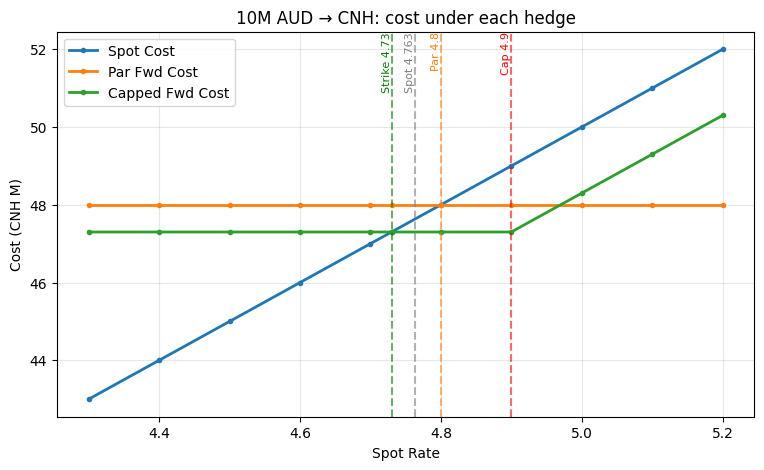

In [11]:
# Chart 1: what we pay under each choice as spot moves (CNH M)
ax = df.set_index("Spot Rate")[["Spot Cost", "Par Fwd Cost", "Capped Fwd Cost"]].plot(figsize=(9, 5), marker="o", ms=3, lw=2)
for x, lbl, c in [(spot, f"Spot {spot:.3f}", "grey"), (strike, f"Strike {strike}", "green"), (par_forward_rate, f"Par {par_forward_rate}", "tab:orange"), (cap, f"Cap {cap}", "red")]:
    ax.axvline(x, ls="--", c=c, alpha=.6); ax.text(x, ax.get_ylim()[1], lbl, c=c, rotation=90, va="top", ha="right", fontsize=8)
ax.set(title=f"{aud_notional}M AUD → CNH: cost under each hedge", ylabel="Cost (CNH M)"); ax.grid(alpha=.3)
plt.show()

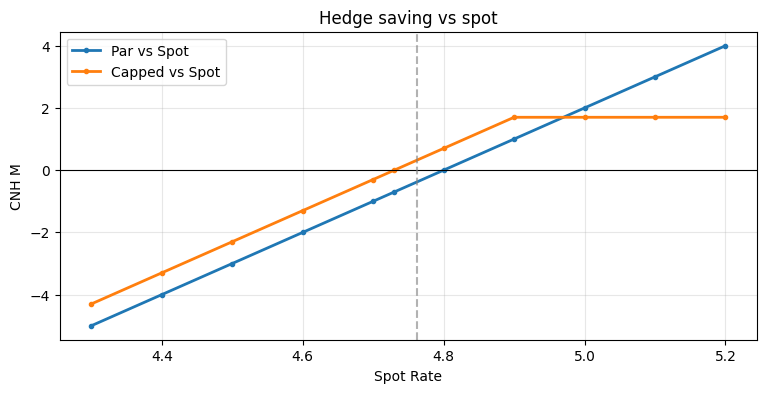

In [12]:
# Chart 2: gain/loss vs simply buying at spot (above zero = hedge won)
ax = df.set_index("Spot Rate")[["Par vs Spot", "Capped vs Spot"]].plot(figsize=(9, 4), marker="o", ms=3, lw=2)
ax.axhline(0, c="k", lw=.8); ax.axvline(spot, ls="--", c="grey", alpha=.6)
ax.set(title="Hedge saving vs spot", ylabel="CNH M"); ax.grid(alpha=.3)
plt.show()

## Results Breakdown

In [13]:
# Result breakdown
breakeven  = par_forward_rate + rebate / aud_notional
no_hedge   = min(strike, par_forward_rate)

# Cheapest option for each scenario
def cheapest(rate):
    costs = {"No Hedge":   rate,
             "Par Forward":    par_forward_rate,
             "Capped Forward": strike if rate <= cap else rate - rebate / aud_notional}
    return min(costs, key=costs.get)

views = {"AUD weakens significantly  (-8%)": spot * 0.92,
         "AUD weakens moderately     (-3%)": spot * 0.97,
         "AUD holds current level    ( 0%)": spot,
         "AUD strengthens moderately (+3%)": spot * 1.03,
         "AUD strengthens sharply    (+8%)": spot * 1.08}

print("At the settlement rate:")
print(f"- Below {no_hedge:.2f}: spot is cheapest, both hedges cost money.")
print(f"- {no_hedge:.2f} to {breakeven:.2f}: the capped forward is cheapest.")
print(f"- Above {breakeven:.2f}: the par forward is cheapest, though capped still beats spot by {rebate:.2f} CNH M.\n")
print("#-----"*15+"#")
print("If at the time of settlement:")
for label, rate in views.items():
    print(f"{label} ~{rate:.2f}    |   Cheapest: {cheapest(rate)}")


At the settlement rate:
- Below 4.73: spot is cheapest, both hedges cost money.
- 4.73 to 4.97: the capped forward is cheapest.
- Above 4.97: the par forward is cheapest, though capped still beats spot by 1.70 CNH M.

#-----#-----#-----#-----#-----#-----#-----#-----#-----#-----#-----#-----#-----#-----#-----#
If at the time of settlement:
AUD weakens significantly  (-8%) ~4.38    |   Cheapest: No Hedge
AUD weakens moderately     (-3%) ~4.62    |   Cheapest: No Hedge
AUD holds current level    ( 0%) ~4.76    |   Cheapest: Capped Forward
AUD strengthens moderately (+3%) ~4.91    |   Cheapest: Capped Forward
AUD strengthens sharply    (+8%) ~5.14    |   Cheapest: Par Forward
